# 01. 탐색적 데이터 분석 (EDA)

## STEP 0. 라이브러리 불러오기

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

print('라이브러리 로드 완료')

라이브러리 로드 완료


## STEP 1. 데이터 로드 및 KR 필터링 (약 2~3분 소요)

In [2]:
import csv

kr_rows = []
filepath = '/Users/eunseoklee/Downloads/ml/trending_yt_videos_113_countries.csv'

with open(filepath, encoding='utf-8') as f:
    reader = csv.DictReader(f)
    for row in reader:
        if row['country'] == 'KR':
            kr_rows.append(row)

df_raw = pd.DataFrame(kr_rows)
print(f'KR 원본 행 수: {len(df_raw):,}')
df_raw.head()

KR 원본 행 수: 48,341


,title,channel_name,daily_rank,daily_movement,weekly_movement,snapshot_date,country,view_count,like_count,comment_count,description,thumbnail_url,video_id,channel_id,video_tags,kind,publish_date,langauge
0,Smile For You,ISEGYE IDOL - Topic,1,49,49,2026-06-20,KR,35209,2581,131,Provided to YouTube by GENIE MUSIC\n\nSmile Fo...,https://i.ytimg.com/vi/IJcbS_dQABk/mqdefault.jpg,IJcbS_dQABk,UChQveKKV7nZHLSGJaAKOkHA,"ISEGYE IDOL, 이세계아이돌, Smile For You",youtube#video,2026-06-19 00:00:00+00:00,ko
1,진짜 떴습니다. ≪스파이더맨: 브랜드뉴데이≫ 메인 예고편 리뷰 & 떡밥 나노 분석 총정리,무비띵크_Movie Think,2,0,48,2026-06-20,KR,624983,9668,1159,#스파이더맨브랜드뉴데이 #스파이더맨 #브랜드뉴데이\n🎬 진짜 떴습니다. ≪스파이더맨...,https://i.ytimg.com/vi/SV7EDrgTmPw/mqdefault.jpg,SV7EDrgTmPw,UCKBzr20577Xcn0LJoRVES_A,"영화리뷰, 영화추천, 무비띵크, 마블, 마블영화, 마블유튜브, 마블유튜버, 마블띵크...",youtube#video,2026-06-18 00:00:00+00:00,ko
2,다딱이 감독관,랄로,3,0,47,2026-06-20,KR,694748,5072,670,랄로 풀코스 youtube.com/@랄롱\n치지직 생방송 https://naver....,https://i.ytimg.com/vi/HLSQWGqAW0Y/mqdefault.jpg,HLSQWGqAW0Y,UCD2YO_A_PVMgMDN9jpRrpVA,"랄로, 랄튜브, 김찬호",youtube#video,2026-06-18 00:00:00+00:00,ko
3,Fast Cars & Superstars,Cristian Marchi - Topic,4,6,46,2026-06-20,KR,110227,1327,0,Provided to YouTube by Universal Music Group\n...,https://i.ytimg.com/vi/l26KDHTABxw/mqdefault.jpg,l26KDHTABxw,UCfc-IfX9K_qr9jBF5lFA9-w,"Cristian Marchi, Reverend Haus, Fast Cars & Su...",youtube#video,2026-06-18 00:00:00+00:00,en
4,[스파이더맨: 브랜드 뉴 데이] 메인 예고편,소니픽쳐스코리아,5,0,45,2026-06-20,KR,1497359,19698,3050,모두가 그를 잊었지만\n세상은 그가 필요하다\n\n[스파이더맨: 브랜드 뉴 데이] ...,https://i.ytimg.com/vi/dosbhD_1LIo/mqdefault.jpg,dosbhD_1LIo,UCY2wHBgv2W30w6lqoLxq99g,,youtube#video,2026-06-17 00:00:00+00:00,en


## STEP 2. 데이터 타입 변환

In [3]:
df = df_raw.copy()

for col in ['view_count','like_count','comment_count','daily_rank','daily_movement','weekly_movement']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df['snapshot_date'] = pd.to_datetime(df['snapshot_date'])
df['publish_date']  = pd.to_datetime(df['publish_date'], utc=True).dt.tz_localize(None)

print('=== 결측치 현황 ===')
print(df.isnull().sum())

=== 결측치 현황 ===
title              0
channel_name       0
daily_rank         0
daily_movement     0
weekly_movement    0
snapshot_date      0
country            0
view_count         0
like_count         0
comment_count      0
description        0
thumbnail_url      0
video_id           0
channel_id         0
video_tags         0
kind               0
publish_date       0
langauge           0
dtype: int64


## STEP 3. 영상별 집계 (중복 제거)

In [4]:
agg = df.groupby('video_id').agg(
    title         = ('title', 'first'),
    channel_name  = ('channel_name', 'first'),
    view_count    = ('view_count', 'max'),
    like_count    = ('like_count', 'max'),
    comment_count = ('comment_count', 'max'),
    best_rank     = ('daily_rank', 'min'),
    trending_days = ('snapshot_date', 'nunique'),
    first_trend   = ('snapshot_date', 'min'),
    publish_date  = ('publish_date', 'first'),
    video_tags    = ('video_tags', 'first'),
    language      = ('langauge', 'first'),
).reset_index()

print(f'고유 영상 수: {len(agg):,}')
agg.head(3)

고유 영상 수: 19,129


,video_id,title,channel_name,view_count,like_count,comment_count,best_rank,trending_days,first_trend,publish_date,video_tags,language
0,--b0x4XO6_g,"붉은사막 플레이 약 30시간 째, 중간 소감입니다",중년게이머 김실장,172407,3506,1290,17,1,2026-03-27,2026-03-26,,ko
1,-03OtM9D-fU,멕시코 vs 대한민국 - FIFA 월드컵 2026 | 조별리그 | 손흥민 vs 멕시...,Alone Gaming,100509,1604,101,20,1,2026-06-19,2026-06-18,"멕시코, 대한민국, 손흥민, FIFA 월드컵 2026, 조별리그, 멕시코 대한민국 ...",ko
2,-0ICh3CmHVs,[EN/JP] [#WSWF/3회 선공개] 리더 계급 메인 댄서? 뺏어줄게!,The CHOOM (더 춤),1369114,15734,3860,3,3,2025-06-08,2025-06-07,"Dance, Mnet, SWF, SWF3, WorldofSWF, 댄스, 스우파, 스...",en-US


## STEP 6. 탐색적 데이터 분석 (EDA)

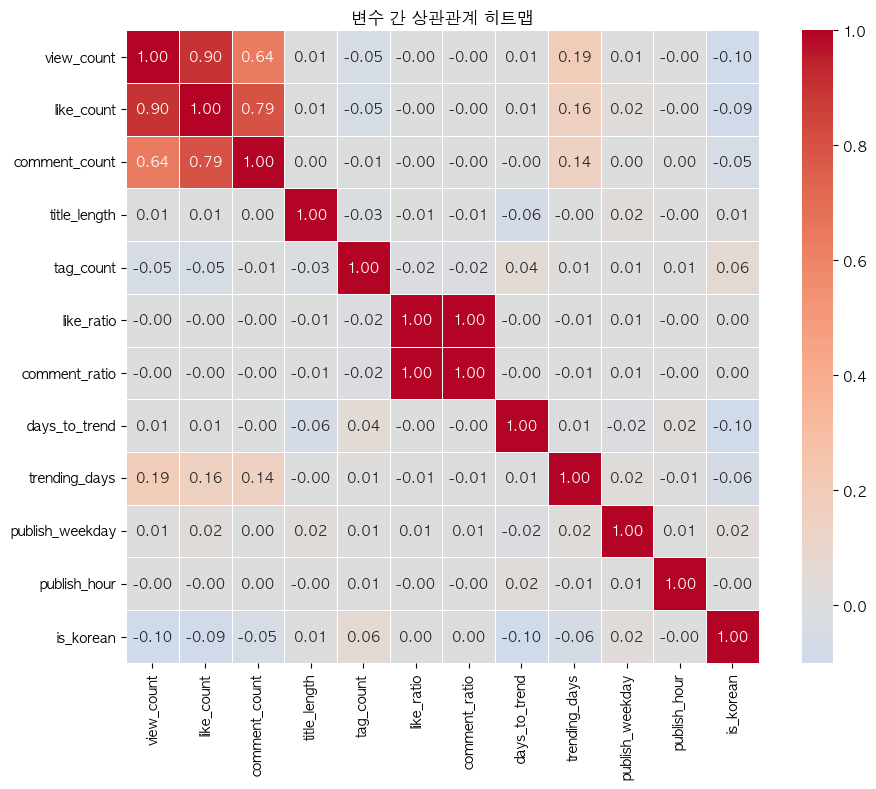

In [ ]:
num_cols = ['view_count','like_count','comment_count','title_length','tag_count',
            'like_ratio','comment_ratio','days_to_trend','trending_days',
            'publish_weekday','publish_hour','is_korean']
corr = df_ml[num_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True, linewidths=0.5)
plt.title('변수 간 상관관계 히트맵')
plt.tight_layout()
plt.show()

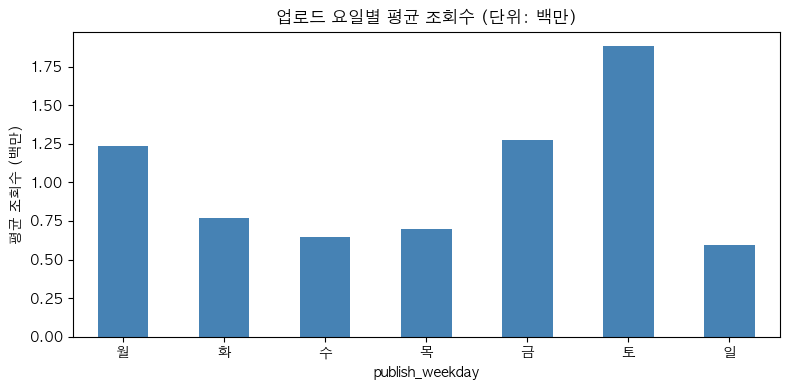

In [ ]:
day_labels = ['월','화','수','목','금','토','일']
day_avg = df_ml.groupby('publish_weekday')['view_count'].mean() / 1e6

plt.figure(figsize=(8, 4))
day_avg.plot(kind='bar', color='steelblue')
plt.xticks(range(7), day_labels, rotation=0)
plt.title('업로드 요일별 평균 조회수 (단위: 백만)')
plt.ylabel('평균 조회수 (백만)')
plt.tight_layout()
plt.show()

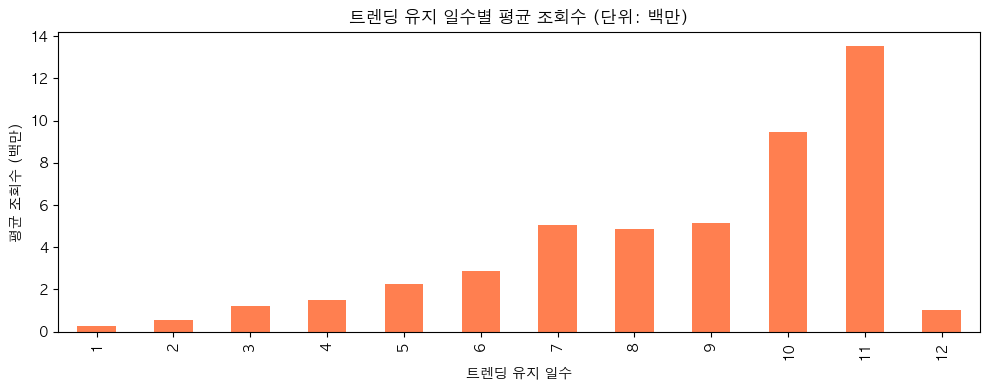

In [ ]:
trend_avg = df_ml.groupby('trending_days')['view_count'].mean() / 1e6

plt.figure(figsize=(10, 4))
trend_avg[:30].plot(kind='bar', color='coral')
plt.title('트렌딩 유지 일수별 평균 조회수 (단위: 백만)')
plt.xlabel('트렌딩 유지 일수')
plt.ylabel('평균 조회수 (백만)')
plt.tight_layout()
plt.show()